In [1]:
# ==============================================================================
# NOTEBOOK 4 : RÉGRESSION - PRÉDICTION DU CHIFFRE D'AFFAIRES (MonetaryTotal)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("="*60)
print("1. PRÉPARATION DES DONNÉES POUR LA RÉGRESSION")
print("="*60)

# 1. Chargement des données pré-traitées
data_dir = "../data/train_test" 
X_train = pd.read_csv(f"{data_dir}/X_train.csv")
X_test = pd.read_csv(f"{data_dir}/X_test.csv")

# 2. Isolement de la variable cible (MonetaryTotal)
# On retire MonetaryTotal des features (X) pour en faire notre target (y)
y_train_reg = X_train.pop("MonetaryTotal")
y_test_reg = X_test.pop("MonetaryTotal")

print(f"Dimensions X_train : {X_train.shape}")
print(f"Dimensions y_train_reg : {y_train_reg.shape}")

print("\n" + "="*60)
print("2. ENTRAÎNEMENT ET COMPARAISON DES MODÈLES")
print("="*60)

# 3. Définition des modèles de régression
reg_models = {
    "Régression Linéaire": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# 4. Entraînement et Évaluation
results = {}

for name, model in reg_models.items():
    # Entraînement
    model.fit(X_train, y_train_reg)
    
    # Prédiction sur le set de test
    y_pred = model.predict(X_test)
    
    # Calcul des métriques
    r2 = r2_score(y_test_reg, y_pred)
    mae = mean_absolute_error(y_test_reg, y_pred)
    mse = mean_squared_error(y_test_reg, y_pred)
    
    results[name] = {"R2": r2, "MAE": mae, "MSE": mse}
    
    print(f"\n--- {name} ---")
    print(f"Score R² (Précision globale) : {r2:.4f}")
    print(f"Erreur Moyenne Absolue (MAE) : {mae:.4f} (écart moyen par rapport à la réalité)")

print("\n" + "="*60)
print("Modélisation terminée ! ✅")

1. PRÉPARATION DES DONNÉES POUR LA RÉGRESSION
Dimensions X_train : (3497, 44)
Dimensions y_train_reg : (3497,)

2. ENTRAÎNEMENT ET COMPARAISON DES MODÈLES

--- Régression Linéaire ---
Score R² (Précision globale) : 0.4563
Erreur Moyenne Absolue (MAE) : 0.2163 (écart moyen par rapport à la réalité)

--- Random Forest Regressor ---
Score R² (Précision globale) : 0.7084
Erreur Moyenne Absolue (MAE) : 0.0455 (écart moyen par rapport à la réalité)

Modélisation terminée ! ✅


C:\Users\user\AppData\Local\Temp\ipykernel_18816\4292457718.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Variable', palette='viridis')


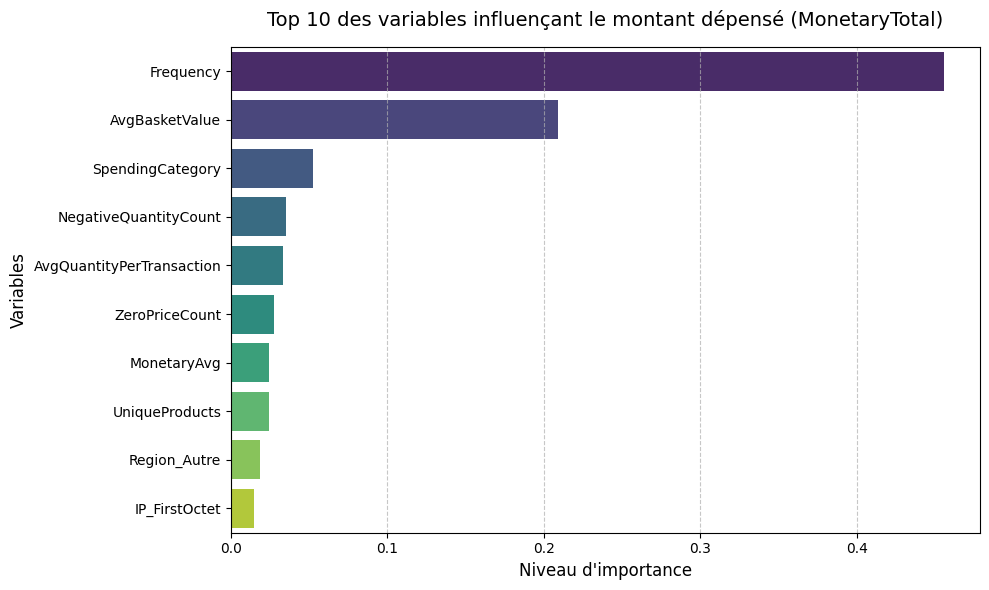

--- DÉTAIL DU TOP 5 ---
                 Variable  Importance
                Frequency    0.455975
           AvgBasketValue    0.209145
         SpendingCategory    0.052100
    NegativeQuantityCount    0.035102
AvgQuantityPerTransaction    0.033152


In [2]:
# ==============================================================================
# CELLULE 2 : IMPORTANCE DES VARIABLES (Qu'est-ce qui drive le CA ?)
# ==============================================================================

# 1. On récupère le modèle Random Forest Regressor qui a été entraîné dans la cellule d'avant
rf_model = reg_models["Random Forest Regressor"]

# 2. On crée un tableau associant chaque colonne à son score d'importance
importances = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. Affichage graphique (Top 10)
plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='Importance', y='Variable', palette='viridis')

plt.title("Top 10 des variables influençant le montant dépensé (MonetaryTotal)", fontsize=14, pad=15)
plt.xlabel("Niveau d'importance", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Affichage des valeurs exactes en texte
print("--- DÉTAIL DU TOP 5 ---")
print(importances.head(5).to_string(index=False))

Variables retirées pour forcer l'analyse comportementale : ['AvgBasketValue']

Nouveau Score R² (sans les variables évidentes) : 0.5756


C:\Users\user\AppData\Local\Temp\ipykernel_18816\1700847032.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_strict.head(10), x='Importance', y='Variable', palette='magma')


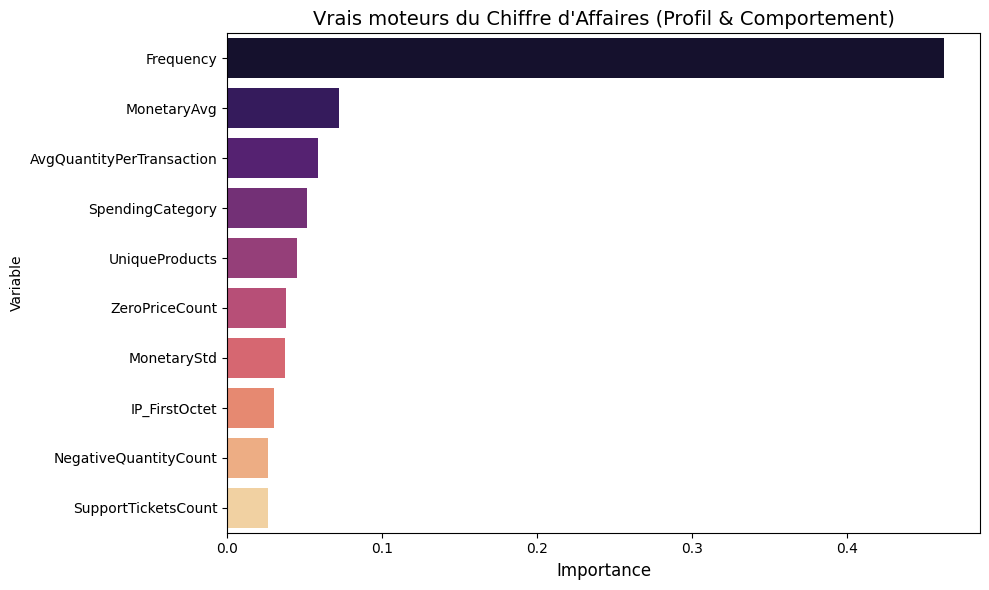

In [3]:
# ==============================================================================
# CELLULE CORRIGÉE : RÉGRESSION SANS DATA LEAKAGE FINANCIER
# ==============================================================================

# 1. On retire les variables "évidentes" (Fuite de données / Tautologie)
# Adapte ces noms de colonnes exactement comme ils sont écrits dans ton X_train
leaky_columns = ['TotalQuantity', 'AvgBasketValue', 'MaxBasketValue', 'MinBasketValue']
cols_to_drop = [col for col in leaky_columns if col in X_train.columns]

X_train_strict = X_train.drop(columns=cols_to_drop)
X_test_strict = X_test.drop(columns=cols_to_drop)

print(f"Variables retirées pour forcer l'analyse comportementale : {cols_to_drop}")

# 2. Entraînement du modèle Random Forest sur les données strictes
rf_strict = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_strict.fit(X_train_strict, y_train_reg)

# 3. Évaluation
y_pred_strict = rf_strict.predict(X_test_strict)
r2_strict = r2_score(y_test_reg, y_pred_strict)
print(f"\nNouveau Score R² (sans les variables évidentes) : {r2_strict:.4f}")

# 4. Nouvelle Feature Importance
importances_strict = pd.DataFrame({
    'Variable': X_train_strict.columns,
    'Importance': rf_strict.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_strict.head(10), x='Importance', y='Variable', palette='magma')
plt.title("Vrais moteurs du Chiffre d'Affaires (Profil & Comportement)", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.tight_layout()
plt.show()